<a href="https://colab.research.google.com/github/Andrew-lee0615/Quant-Strategies/blob/main/Strategy_01_SMA_Crossover_SPY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

/tmp/ipykernel_7575/647947248.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='10y', interval='1d')['Close'].squeeze().to_frame(name='Close')
[*********************100%***********************]  1 of 1 completed


--- SPY Original Strategy Report (10Y) ---
Total Invested: $410,200
Final Portfolio Value: $753,129.15
Total Return: 83.60%
CAGR: 6.26%
Max Drawdown (MDD): -27.49%
----------------------------------------


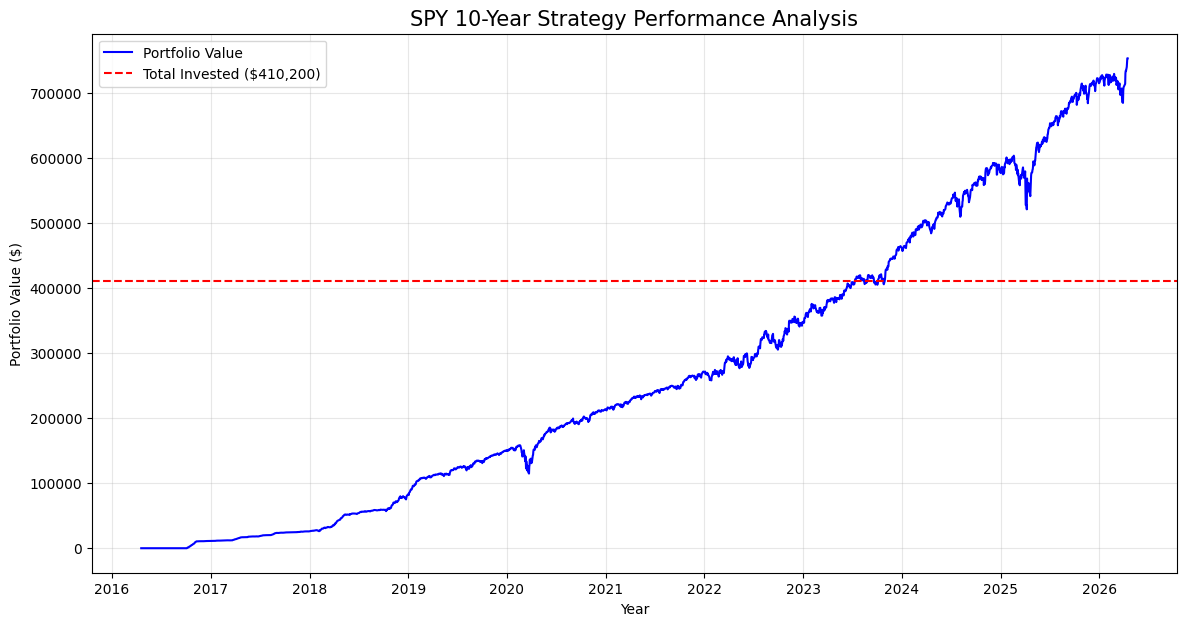

In [ ]:

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data Retrieval (Changed to 10y)
ticker = 'SPY'
df = yf.download(ticker, period='10y', interval='1d')['Close'].squeeze().to_frame(name='Close')

# 2. Moving Average Calculation
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA60'] = df['Close'].rolling(window=60).mean()
df['MA120'] = df['Close'].rolling(window=120).mean()

# 3. Simulation Variables
cash = 0
shares = 0
total_invested = 0
portfolio_values = []

# 4. Backtesting Loop (Original Logic)
for i in range(len(df)):
    current_price = df['Close'].iloc[i]
    ma20 = df['MA20'].iloc[i]
    ma60 = df['MA60'].iloc[i]
    ma120 = df['MA120'].iloc[i]

    if pd.isna(ma120):
        portfolio_values.append(0)
        continue

    # --- [BUY] Layered Logic ---
    buy_amount = 0
    if current_price <= ma120:
        buy_amount = 600
    elif current_price <= ma60:
        buy_amount = 400
    elif current_price <= ma20:
        buy_amount = 200

    if buy_amount > 0:
        shares += buy_amount / current_price
        total_invested += buy_amount

    # --- [SELL] 10% Profit Taking ---
    if current_price >= ma20 * 1.10 and shares > 0:
        sell_shares = shares * 0.2
        cash += sell_shares * current_price
        shares -= sell_shares

    # Record Total Value
    portfolio_values.append((shares * current_price) + cash)

df['Portfolio_Value'] = portfolio_values

# 5. Performance Metrics (10-Year Period)
df['Peak'] = df['Portfolio_Value'].cummax()
df['Drawdown'] = (df['Portfolio_Value'] - df['Peak']) / df['Peak']
final_mdd = df['Drawdown'].min() * 100

final_val = df['Portfolio_Value'].iloc[-1]
total_return = ((final_val - total_invested) / total_invested) * 100
years = 10
cagr = (((final_val / total_invested) ** (1/years)) - 1) * 100

# 6. Final Report Output
print(f"--- {ticker} Original Strategy Report (10Y) ---")
print(f"Total Invested: ${total_invested:,.0f}")
print(f"Final Portfolio Value: ${final_val:,.2f}")
print(f"Total Return: {total_return:.2f}%")
print(f"CAGR: {cagr:.2f}%")
print(f"Max Drawdown (MDD): {final_mdd:.2f}%")
print("-" * 40)

# Visualization
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Portfolio_Value'], label='Portfolio Value', color='blue')
plt.axhline(y=total_invested, color='red', linestyle='--', label=f'Total Invested (${total_invested:,.0f})')
plt.title(f'{ticker} 10-Year Strategy Performance Analysis', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_2358/2718697769.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='10y', interval='1d')['Close'].squeeze().to_frame(name='Close')
[*********************100%***********************]  1 of 1 completed


--- SPY 10-Year Strategy Report ---
Total Return: 2.47%
CAGR: 0.24%
Max Drawdown (MDD): -4.01%
Total Invested: $410,200
Final Value: $420,339.97


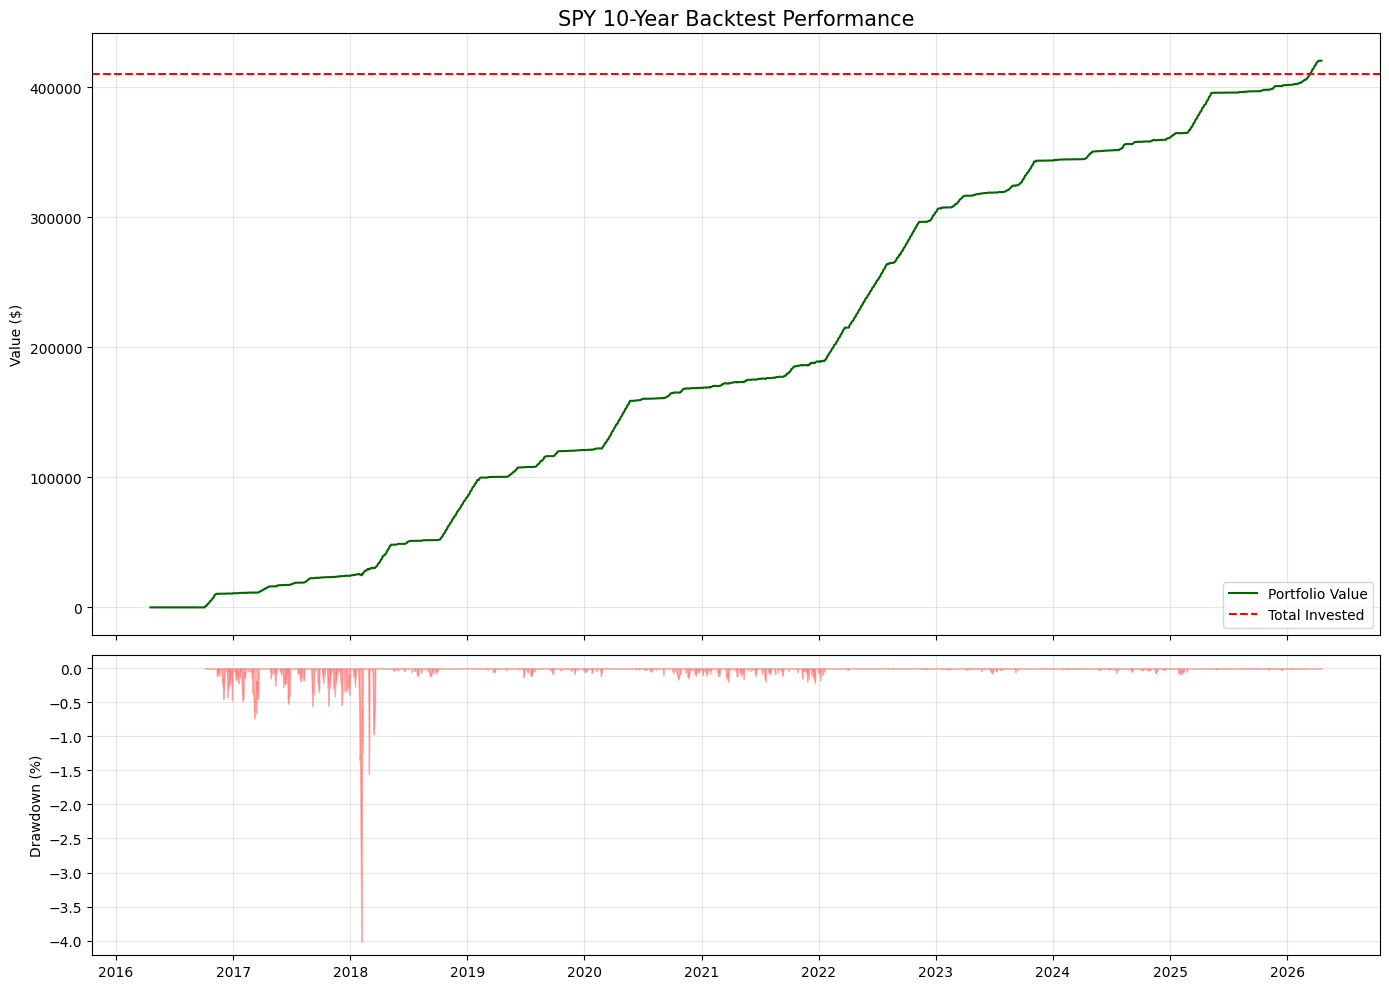

In [4]:
# 1. Data Retrieval (10y Period)
ticker = 'SPY'
df = yf.download(ticker, period='10y', interval='1d')['Close'].squeeze().to_frame(name='Close')

# 2. Moving Average Calculation
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA60'] = df['Close'].rolling(window=60).mean()
df['MA120'] = df['Close'].rolling(window=120).mean()

# 3. Simulation Variables
cash = 0
shares = 0
total_invested = 0
portfolio_values = []

# 4. Backtesting Loop
for i in range(len(df)):
    current_price = df['Close'].iloc[i]
    ma10 = df['MA10'].iloc[i]
    ma20 = df['MA20'].iloc[i]
    ma60 = df['MA60'].iloc[i]
    ma120 = df['MA120'].iloc[i]

    if pd.isna(ma120):
        portfolio_values.append(0)
        continue

    # --- [BUY LOGIC] ---
    buy_amount = 0
    # MA120 -5% Zone: Aggressive Buy
    if current_price <= ma120 * 0.95:
        buy_amount = 600
    # Tiered Support Buy
    elif current_price <= ma120:
        buy_amount = 600
    elif current_price <= ma60:
        buy_amount = 400
    elif current_price <= ma20:
        buy_amount = 200

    if buy_amount > 0:
        shares += buy_amount / current_price
        total_invested += buy_amount

    # --- [SELL LOGIC] ---
    # 1. Profit Taking: 15% sell if price > MA10 * 1.05
    if current_price >= ma10 * 1.05 and shares > 0:
        sell_shares = shares * 0.15
        cash += sell_shares * current_price
        shares -= sell_shares

    # 2. Risk Management: 20% sell if price < MA120
    elif current_price < ma120 and shares > 0:
        sell_shares = shares * 0.20
        cash += sell_shares * current_price
        shares -= sell_shares

    portfolio_values.append((shares * current_price) + cash)

df['Portfolio_Value'] = portfolio_values

# 5. Performance Metrics
df['Peak'] = df['Portfolio_Value'].cummax()
df['Drawdown'] = (df['Portfolio_Value'] - df['Peak']) / df['Peak']
final_mdd = df['Drawdown'].min() * 100
final_val = df['Portfolio_Value'].iloc[-1]
total_return = ((final_val - total_invested) / total_invested) * 100
years = 10
cagr = (((final_val / total_invested) ** (1/years)) - 1) * 100

# 6. Output & Visualization
print(f"--- {ticker} 10-Year Strategy Report ---")
print(f"Total Return: {total_return:.2f}%")
print(f"CAGR: {cagr:.2f}%")
print(f"Max Drawdown (MDD): {final_mdd:.2f}%")
print(f"Total Invested: ${total_invested:,.0f}")
print(f"Final Value: ${final_val:,.2f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Equity Curve
ax1.plot(df.index, df['Portfolio_Value'], label='Portfolio Value', color='darkgreen', linewidth=1.5)
ax1.axhline(y=total_invested, color='red', linestyle='--', label='Total Invested')
ax1.set_title(f'{ticker} 10-Year Backtest Performance', fontsize=15)
ax1.set_ylabel('Value ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Drawdown
ax2.fill_between(df.index, df['Drawdown'] * 100, 0, color='red', alpha=0.3)
ax2.set_ylabel('Drawdown (%)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2358/443995902.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('SPY', start='2000-01-01', end='2026-04-18')
[*********************100%***********************]  1 of 1 completed


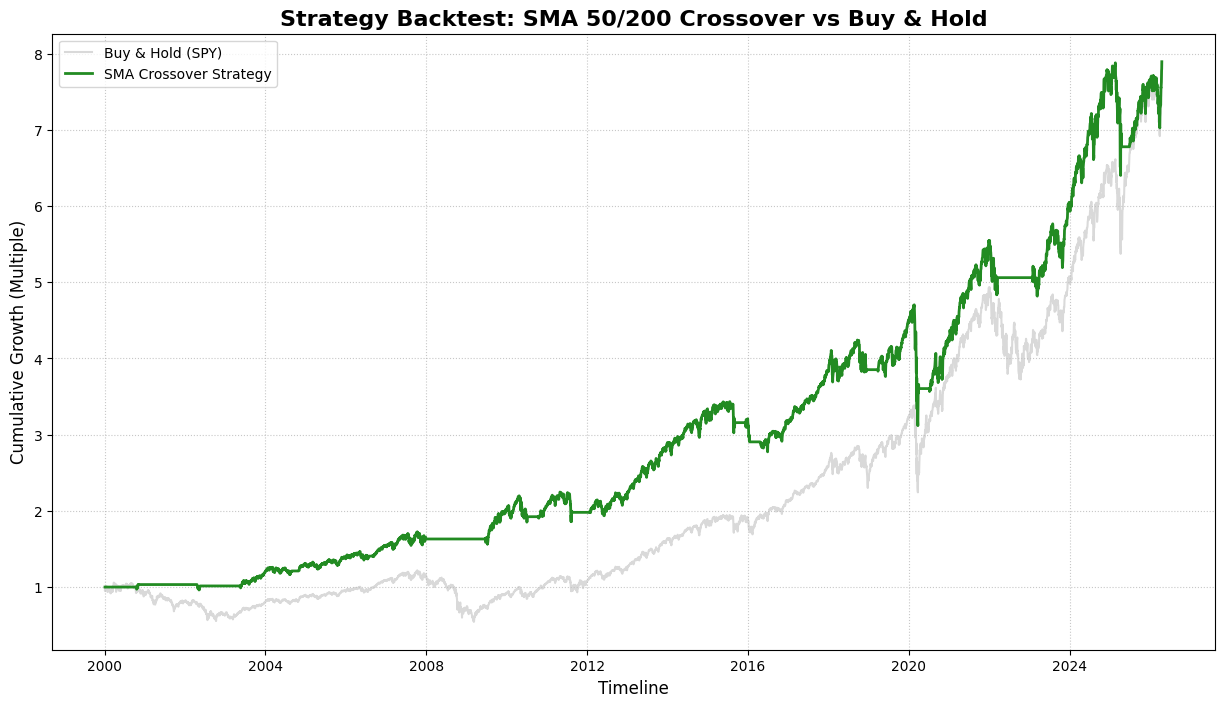

--- Strategy Performance Metrics ---
Total Market Return: 7.77x
Total Strategy Return: 7.89x


In [5]:
# 1. Reliable Data Acquisition
# Handling potential MultiIndex issues from yfinance
data = yf.download('SPY', start='2000-01-01', end='2026-04-18')

# Flatten MultiIndex columns if present
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Determine the correct column for price (Priority: Adj Close -> Close)
price_col = 'Adj Close' if 'Adj Close' in data.columns else 'Close'

# 2. Indicator Engineering
# Generating moving averages for trend identification
data['SMA50'] = data[price_col].rolling(window=50).mean()
data['SMA200'] = data[price_col].rolling(window=200).mean()

# 3. Signal Generation (Logic Implementation)
# 1 = Long (Market On), 0 = Cash (Market Off)
data['Signal'] = 0
data.loc[data['SMA50'] > data['SMA200'], 'Signal'] = 1

# Shift signal by 1 day to prevent 'Look-ahead Bias'
# (We trade at the next day's open after the signal is generated)
data['Position'] = data['Signal'].shift(1)

# 4. Performance Calculation
data['Market_Return'] = data[price_col].pct_change()
data['Strategy_Return'] = data['Market_Return'] * data['Position']

# Compute Cumulative Returns (Compound growth)
data['Cum_Market_Return'] = (1 + data['Market_Return']).cumprod()
data['Cum_Strategy_Return'] = (1 + data['Strategy_Return']).cumprod()

# 5. Professional Visualization
plt.figure(figsize=(15, 8))
plt.plot(data['Cum_Market_Return'], label='Buy & Hold (SPY)', color='silver', alpha=0.6)
plt.plot(data['Cum_Strategy_Return'], label='SMA Crossover Strategy', color='forestgreen', linewidth=2)

plt.title('Strategy Backtest: SMA 50/200 Crossover vs Buy & Hold', fontsize=16, fontweight='bold')
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Cumulative Growth (Multiple)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# 6. Final Performance Summary
print(f"--- Strategy Performance Metrics ---")
print(f"Total Market Return: {data['Cum_Market_Return'].iloc[-1]:.2f}x")
print(f"Total Strategy Return: {data['Cum_Strategy_Return'].iloc[-1]:.2f}x")